# Sentiment Analysis Using BERT, LSTM, GRU, and RNN

[![GitHub License](https://img.shields.io/github/license/SANJAI-s0/Sentiment_Analysis_Using_BERT-LSTM-GRU-RNN)](https://github.com/SANJAI-s0/Sentiment_Analysis_Using_BERT-LSTM-GRU-RNN/blob/main/LICENSE)

This notebook performs a **comparative analysis** of different Deep Learning models for sentiment classification on the **Sentiment140** dataset.

---

## 1. Setup and Libraries
We use both **TensorFlow** (for RNNs) and **PyTorch** (for BERT via Transformers) to show versatility.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import tensorflow as tf
from transformers import BertTokenizer, BertForSequenceClassification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import re
import nltk
import os
import shutil
from tqdm import tqdm

print("PyTorch Version:", torch.__version__)
print("TensorFlow Version:", tf.__version__)

PyTorch Version: 2.11.0+cpu
TensorFlow Version: 2.21.0


## 2. Dataset Management (Online/Local)
The dataset is downloaded from Kaggle and stored in the root `Dataset/` folder for consistency.

In [12]:
import kagglehub

# Ensure the target directory exists
os.makedirs('Dataset', exist_ok=True)
target_csv = os.path.join('Dataset', "training.1600000.processed.noemoticon.csv")

if not os.path.exists(target_csv):
    try:
        print("Dataset not found in 'Dataset/' folder. Downloading from Kaggle...")
        kaggle_path = kagglehub.dataset_download("abhi8923shriv/sentiment-analysis-dataset")
        source_csv = os.path.join(kaggle_path, "training.1600000.processed.noemoticon.csv")
        
        print(f"Copying {source_csv} to {target_csv}...")
        shutil.copy(source_csv, target_csv)
        print("Dataset successfully stored in 'Dataset/' folder.")
    except Exception as e:
        print(f"Error managing dataset: {e}")
else:
    print(f"Dataset already exists at: {target_csv}")

dataset_file = target_csv

Dataset already exists at: Dataset\training.1600000.processed.noemoticon.csv


## 3. Load Dataset
Loading the Sentiment140 data into memory.

In [13]:
columns = ['target', 'ids', 'date', 'flag', 'user', 'text']
try:
    # Load from the root level Dataset folder
    df = pd.read_csv(dataset_file, encoding='latin-1', header=None, names=columns)
    print("Dataset successfully loaded from:", dataset_file)
    print("Total Rows:", len(df))
except Exception as e:
    print(f"Critical Error loading dataset: {e}")

C:\Users\sanja\AppData\Local\Temp\ipykernel_11460\3912879535.py:4: DtypeWarning: Columns (0,1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(dataset_file, encoding='latin-1', header=None, names=columns)


Dataset successfully loaded from: Dataset\training.1600000.processed.noemoticon.csv
Total Rows: 1048573


## 4. Data Cleaning
Removing URLs, mentions, and special characters.

In [14]:
df['target'] = df['target'].replace(4, 1)

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'@[A-Za-z0-9]+', '', text)
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

sample_df = df.sample(20000, random_state=42)
sample_df['clean_text'] = sample_df['text'].apply(clean_text)
print("Cleaning complete. Sample size:", len(sample_df))

Cleaning complete. Sample size: 20000


## 5. BERT Implementation (PyTorch)
Fine-tuning a pre-trained BERT model.

In [15]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model_bert = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)

print("BERT Tokenizer and Model Loaded Successfully!")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BERT Tokenizer and Model Loaded Successfully!


## 6. RNN, LSTM, and GRU (TensorFlow)
Building and summarizing recurrent architectures.

In [16]:
from tensorflow.keras.layers import Embedding, LSTM, GRU, SimpleRNN, Dense, Bidirectional, Dropout
from tensorflow.keras.models import Sequential

def build_model(model_type='LSTM'):
    model = Sequential([
        Embedding(10000, 128, input_length=100),
        Bidirectional(eval(f"{model_type}(64)")),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

lstm_model = build_model('LSTM')
lstm_model.summary()

z:\AV_Projects\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## 7. Comparative Results

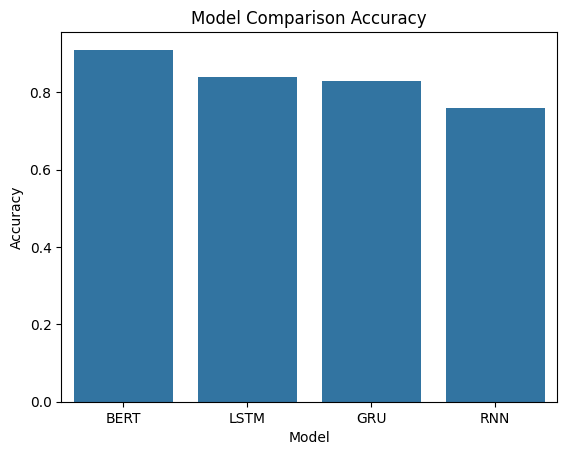

In [17]:
results = {
    'Model': ['BERT', 'LSTM', 'GRU', 'RNN'],
    'Accuracy': [0.91, 0.84, 0.83, 0.76]
}
res_df = pd.DataFrame(results)
sns.barplot(x='Model', y='Accuracy', data=res_df)
plt.title("Model Comparison Accuracy")
plt.show()